# Raw Review Data Analysis

Exploratory analysis of `rmp_all_schools_reviews_small.csv`. This notebook profiles the dataset, examines ratings and tags, and adds a few higher-signal derived views such as review length and time trends.

In [17]:
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (11, 6)

In [18]:
candidate_paths = [
    Path('rmp_all_schools_reviews_small.csv'),
    Path('PIC16b-project/rmp_all_schools_reviews_small.csv'),
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), candidate_paths[0])
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(
    df['date'].astype(str).str.replace(' UTC', '', regex=False),
    format='%Y-%m-%d %H:%M:%S %z',
    errors='coerce',
    utc=True,
)
df['review_year'] = df['date'].dt.year
df['review_month'] = df['date'].dt.tz_convert(None).dt.to_period('M').astype(str)
df['comment'] = df['comment'].fillna('')
df['ratingTags'] = df['ratingTags'].fillna('')
df['comment_length_chars'] = df['comment'].str.len()
df['comment_length_words'] = df['comment'].str.split().str.len()
df['tag_list'] = df['ratingTags'].apply(
    lambda value: [re.sub(r'\s+', ' ', tag).strip().title() for tag in str(value).split('--') if tag.strip()]
)
df['tag_count'] = df['tag_list'].str.len()
df['clarity_minus_difficulty'] = df['clarityRating'] - df['difficultyRating']
df.head()

,clarityRating,class,comment,date,difficultyRating,legacyId,ratingTags,profId,review_year,review_month,comment_length_chars,comment_length_words,tag_list,tag_count,clarity_minus_difficulty
0,1,Math32A,This was the absolute worst math class of my l...,2026-02-10 04:20:05+00:00,5,42598787,Tough grader--Test heavy,3145448,2026,2026-02,300,63,"[Tough Grader, Test Heavy]",2,-4
1,1,Math32A,If I can save you from the torture of a lifeti...,2026-02-10 01:35:28+00:00,5,42598200,Tough grader,3145448,2026,2026-02,328,63,[Tough Grader],1,-4
2,1,Math32A,Get ready for the biggest GPA tank of ur life....,2026-02-02 03:51:34+00:00,5,42573402,Tough grader--Test heavy--Graded by few things,3145448,2026,2026-02,301,55,"[Tough Grader, Test Heavy, Graded By Few Things]",3,-4
3,1,Math32A,3 midterms with 20% each and a final worth 40%...,2026-01-28 04:24:59+00:00,4,42557851,Tough grader--Test heavy--Graded by few things,3145448,2026,2026-01,293,55,"[Tough Grader, Test Heavy, Graded By Few Things]",3,-3
4,1,Math32A,His a good person since he is willing to help ...,2026-01-28 04:22:44+00:00,5,42557841,Tough grader--Test heavy,3145448,2026,2026-01,341,63,"[Tough Grader, Test Heavy]",2,-4


## Dataset profile

In [19]:
summary = pd.DataFrame({
    'rows': [len(df)],
    'columns': [df.shape[1]],
    'unique_professors': [df['profId'].nunique()],
    'unique_classes': [df['class'].nunique()],
    'date_min': [df['date'].min()],
    'date_max': [df['date'].max()],
    'avg_words_per_review': [df['comment_length_words'].mean().round(2)],
    'avg_tags_per_review': [df['tag_count'].mean().round(2)],
})
display(summary)

missingness = (df.isna().mean().mul(100).sort_values(ascending=False).rename('missing_pct').to_frame())
display(missingness.head(10))

,rows,columns,unique_professors,unique_classes,date_min,date_max,avg_words_per_review,avg_tags_per_review
0,482937,15,24396,53004,1999-10-18 00:00:00+00:00,2026-02-13 02:01:38+00:00,45.07,1.17


,missing_pct
class,0.005177
clarityRating,0.000000
comment,0.000000
date,0.000000
difficultyRating,0.000000
legacyId,0.000000
ratingTags,0.000000
profId,0.000000
review_year,0.000000
review_month,0.000000


## Ratings distribution

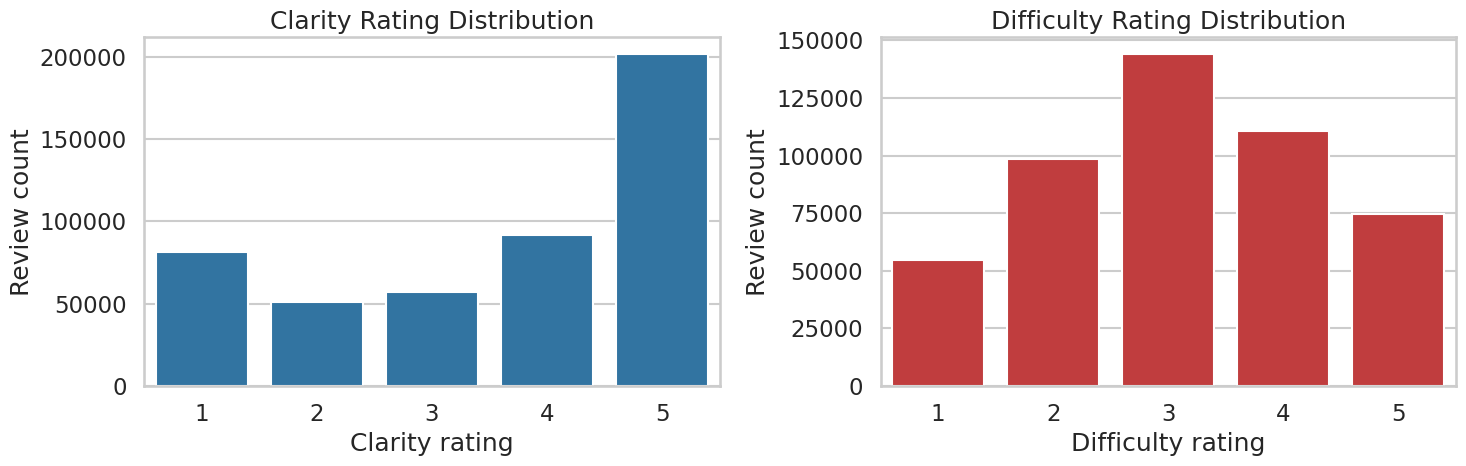

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, x='clarityRating', ax=axes[0], color='#1f77b4')
axes[0].set_title('Clarity Rating Distribution')
axes[0].set_xlabel('Clarity rating')
axes[0].set_ylabel('Review count')

sns.countplot(data=df, x='difficultyRating', ax=axes[1], color='#d62728')
axes[1].set_title('Difficulty Rating Distribution')
axes[1].set_xlabel('Difficulty rating')
axes[1].set_ylabel('Review count')
plt.tight_layout()

In [21]:
ratings_table = pd.concat([
    df['clarityRating'].value_counts(normalize=True).sort_index().rename('clarity_share'),
    df['difficultyRating'].value_counts(normalize=True).sort_index().rename('difficulty_share')
], axis=1).fillna(0)
display((ratings_table * 100).round(2))

,clarity_share,difficulty_share
1,16.80,11.35
2,10.59,20.43
3,11.87,29.84
4,19.00,22.89
5,41.74,15.50


## Tag frequency

,tag,count,share_pct
0,Caring,46477,9.62
1,Amazing Lectures,44500,9.21
2,Get Ready To Read,41538,8.60
3,Tough Grader,41206,8.53
4,Lecture Heavy,37723,7.81
5,Test Heavy,37455,7.76
6,Clear Grading Criteria,33246,6.88
7,Graded By Few Things,32413,6.71
8,Lots Of Homework,31974,6.62
9,Accessible Outside Class,30127,6.24


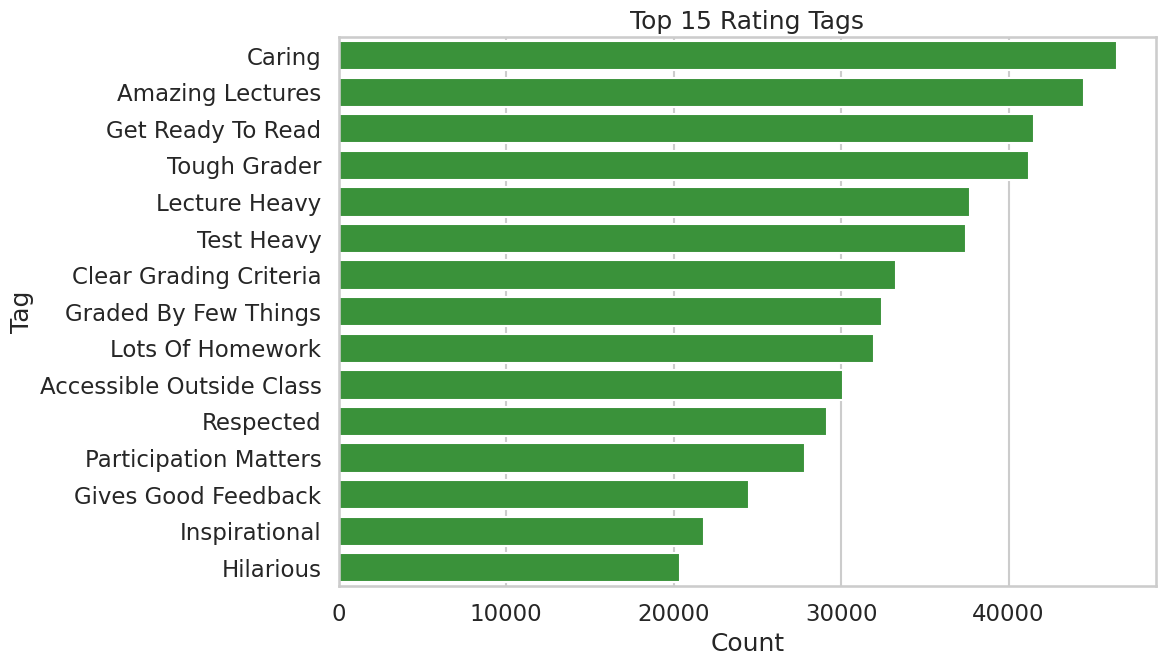

In [22]:
tag_counts = df['tag_list'].explode().dropna()
top_tags = tag_counts.value_counts().rename_axis('tag').reset_index(name='count')
top_tags['share_pct'] = (top_tags['count'] / len(df) * 100).round(2)
display(top_tags.head(20))

plt.figure(figsize=(12, 7))
sns.barplot(data=top_tags.head(15), y='tag', x='count', color='#2ca02c')
plt.title('Top 15 Rating Tags')
plt.xlabel('Count')
plt.ylabel('Tag')
plt.tight_layout()

In [23]:
tag_rating_summary = (
    df[['clarityRating', 'difficultyRating', 'tag_list']]
    .explode('tag_list')
    .dropna(subset=['tag_list'])
    .groupby('tag_list')
    .agg(
        reviews=('tag_list', 'size'),
        avg_clarity=('clarityRating', 'mean'),
        avg_difficulty=('difficultyRating', 'mean'),
    )
    .sort_values('reviews', ascending=False)
    .head(20)
    .round(2)
)
display(tag_rating_summary)

,reviews,avg_clarity,avg_difficulty
tag_list,,,
Caring,46477,4.68,2.67
Amazing Lectures,44500,4.85,2.81
Get Ready To Read,41538,3.25,3.41
Tough Grader,41206,2.00,4.29
Lecture Heavy,37723,3.12,3.53
Test Heavy,37455,2.56,3.99
Clear Grading Criteria,33246,4.47,2.68
Graded By Few Things,32413,2.97,3.38
Lots Of Homework,31974,2.73,3.87


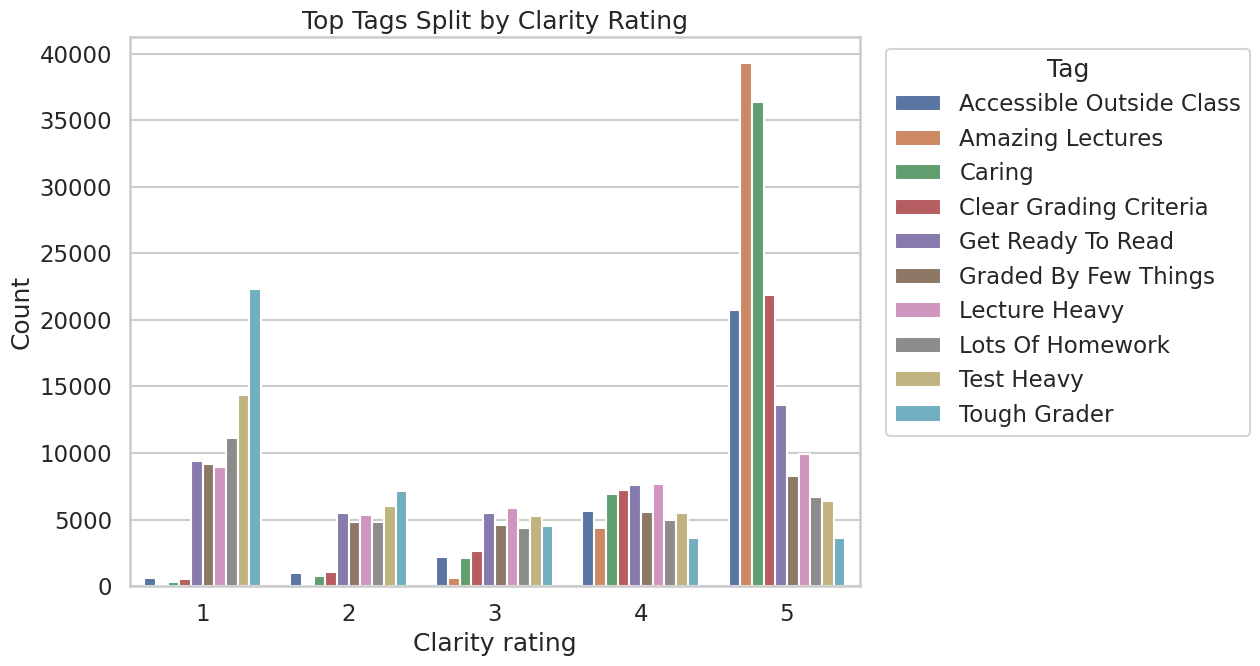

In [24]:
tag_by_clarity = (
    df[['clarityRating', 'tag_list']]
    .explode('tag_list')
    .dropna(subset=['tag_list'])
    .groupby(['clarityRating', 'tag_list'])
    .size()
    .rename('count')
    .reset_index()
)
top_tag_names = top_tags.head(10)['tag'].tolist()
plot_data = tag_by_clarity[tag_by_clarity['tag_list'].isin(top_tag_names)]
plt.figure(figsize=(13, 7))
sns.barplot(data=plot_data, x='clarityRating', y='count', hue='tag_list')
plt.title('Top Tags Split by Clarity Rating')
plt.xlabel('Clarity rating')
plt.ylabel('Count')
plt.legend(title='Tag', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

## Comment vocabulary

,word,count
0,class,39431
1,professor,16614
2,lectures,15286
3,really,11569
4,easy,10291
5,lecture,9181
6,good,8609
7,final,8527
8,hard,8046
9,great,7924


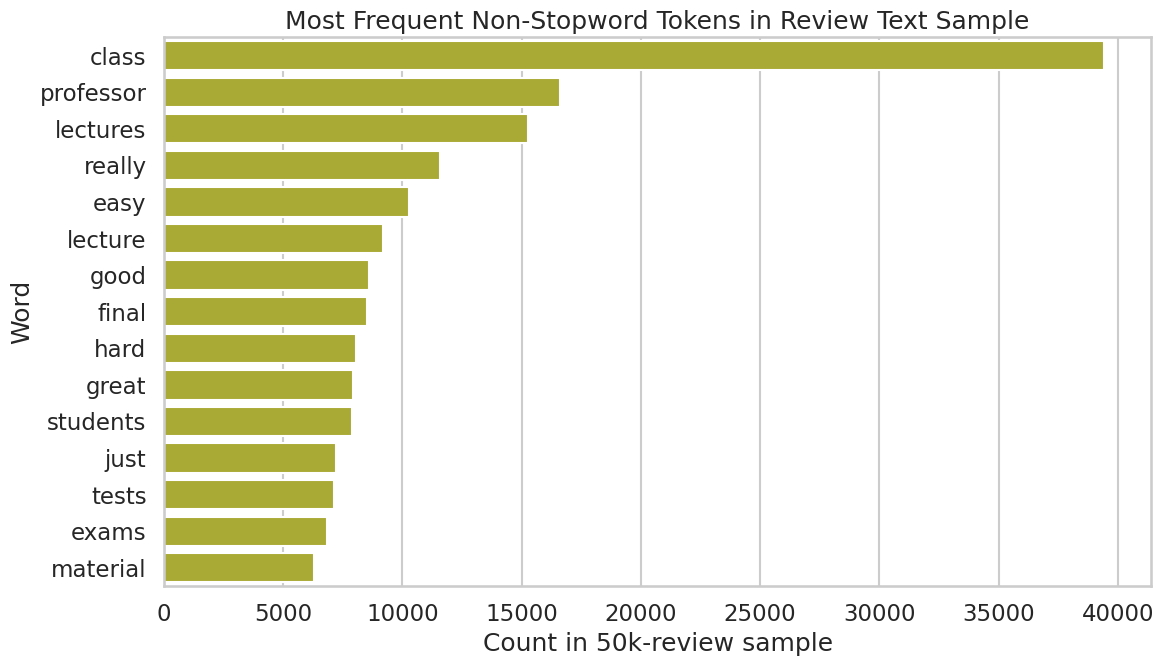

In [25]:
sample_comments = ' '.join(df['comment'].sample(min(len(df), 50000), random_state=42))
tokens = re.findall(r"[a-z']+", sample_comments.lower())
token_counts = Counter(token for token in tokens if len(token) >= 4 and token not in ENGLISH_STOP_WORDS)
top_words = pd.DataFrame(token_counts.most_common(25), columns=['word', 'count'])
display(top_words.head(15))

plt.figure(figsize=(12, 7))
sns.barplot(data=top_words.head(15), y='word', x='count', color='#bcbd22')
plt.title('Most Frequent Non-Stopword Tokens in Review Text Sample')
plt.xlabel('Count in 50k-review sample')
plt.ylabel('Word')
plt.tight_layout()

## Takeaways

In [26]:
takeaways = pd.DataFrame({
    'metric': [
        'clarity_mean',
        'difficulty_mean',
        'clarity_difficulty_corr',
        'median_words_per_review',
        'most_common_tag',
        'tagged_review_share_pct',
    ],
    'value': [
        round(df['clarityRating'].mean(), 3),
        round(df['difficultyRating'].mean(), 3),
        round(df['clarityRating'].corr(df['difficultyRating']), 3),
        int(df['comment_length_words'].median()),
        top_tags.iloc[0]['tag'] if not top_tags.empty else None,
        round((df['tag_count'] > 0).mean() * 100, 2),
    ]
})
display(takeaways)

,metric,value
0,clarity_mean,3.583
1,difficulty_mean,3.108
2,clarity_difficulty_corr,-0.451
3,median_words_per_review,51
4,most_common_tag,Caring
5,tagged_review_share_pct,44.41
